In [2]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2

# Set seed for reproducibility
SEED = 28
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
tf.__version__

'2.16.1'

In [ ]:
model = tf.keras.models.load_model('/kaggle/input/unseen-tomato-images-dataset/sardine_model.keras')

In [ ]:
model.summary()

In [ ]:
input_shape = (224,224,3)
target_size = list(input_shape)[:2]
batch_size = 32

print('Input Shape', input_shape)
print('Target Size', target_size)
print('Batch Size', batch_size)

In [ ]:
def preprocess(image):
    image = cv2.resize(image,target_size)
    image = tf.keras.applications.densenet.preprocess_input(image)
    return image

In [ ]:
datagen = ImageDataGenerator(
    preprocessing_function = preprocess, 
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess,
)

In [ ]:
train = datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/train_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = True,
    seed=SEED
)

val = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/val_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed=SEED
)

test = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/test_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

unseen = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/new sardine segmented dataset/unseen_images',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

app_test = test_datagen.flow_from_directory(
    directory='/kaggle/input/organized-sardine-segmented-dataset/app_testing_sardine_segmented_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
def count_class_images(data, dataset_name='Train'):
    class_counts = {class_name: 0 for class_name in data.class_indices.keys()}
    for label in data.classes:
        class_name = list(data.class_indices.keys())[label]
        class_counts[class_name] += 1
    print(f'{dataset_name} Dataset: {class_counts}')

In [ ]:
count_class_images(train, dataset_name='Train')
count_class_images(val, dataset_name='Validation')
count_class_images(test, dataset_name='Test')
count_class_images(unseen, dataset_name='Unseen')
count_class_images(app_test, dataset_name='App Test')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the callback
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,   
    patience=3,           
    min_lr=1e-7,          
    verbose=1,
    mode = 'min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', 
                               restore_best_weights=True, verbose=1, min_delta=0.01)

checkpoint_filepath = '/kaggle/working/checkpoint.keras'

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
#     save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

In [ ]:
callbacks = [early_stopping, reduce_lr_callback, model_checkpoint_callback]

In [ ]:
model.layers[0].name

In [ ]:
from tensorflow.keras.optimizers import Adam

model.layers[0].trainable = True

model.compile(optimizer=Adam(learning_rate = 1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model.summary()

In [ ]:
history = model.fit(train, validation_data=val, epochs=20, batch_size=batch_size, callbacks=callbacks)

In [ ]:
def plot_accuracy_loss(history, label):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Two subplots: one for accuracy, one for loss

    # Plot accuracy on the left
    ax1.plot(history.history['accuracy'], label=f'Train Accuracy {label}')
    ax1.plot(history.history['val_accuracy'], label=f'Val Accuracy {label}')
    ax1.set_title(f'Accuracy {label}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot loss on the right
    ax2.plot(history.history['loss'], label=f'Train Loss {label}')
    ax2.plot(history.history['val_loss'], label=f'Val Loss {label}')
    ax2.set_title(f'Loss {label}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Plot accuracy and loss for the model without custom callback
plt.figure(figsize=(12, 6))
plot_accuracy_loss(history, label='Training Curves After Fine-Tune')

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred_labels = (y_pred_prob > threshold).astype(int)

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=['Bad', 'Good']))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
evaluate_binary_classification_model(model,val,0.5 )

In [ ]:
evaluate_binary_classification_model(model,test,0.5 )

In [ ]:
evaluate_binary_classification_model(model,unseen,0.5 )

In [ ]:
evaluate_binary_classification_model(model,app_test,0.5 )

In [ ]:
model.save('sardine_final_model_20epochs_k_gpu.keras')

In [ ]:
model.export('sardine_model_20epochs_k_gpu', format='tf')

In [ ]:
! zip -rq sardine_model_20epochs_k_gpu.zip '/kaggle/working/sardine_model_20epochs_k_gpu'

# Testing the model regularly with new data collected

In [ ]:
import os
import shutil
import boto3
from tqdm import tqdm
from datetime import datetime, timedelta

# Set the environment variables
# use your AWS credentials insted of these
os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [5]:
class S3DataDownloader:
    def __init__(self, bucket_name, download_path):
        """
        Initializes the S3DataDownloader instance.

        Args:
            bucket_name (str): The name of the S3 bucket.
            download_path (str): The local directory to download files to.
        """
        self.bucket_name = bucket_name
        self.download_path = download_path
        # Create an S3 client
        self.s3_client = boto3.client('s3')
        self.grouped_objects = self.group_objects_by_date()

    def list_s3_objects(self, bucket_name=None):
        """
        Lists all objects in the specified S3 bucket.

        Args:
            bucket_name (str): The name of the S3 bucket.

        Returns:
            list: A list of objects in the S3 bucket.
        """
        if bucket_name is None:
            bucket_name = self.bucket_name
        object_list = []
        # Use a paginator to iterate through all the objects in the bucket
        paginator = self.s3_client.get_paginator('list_objects_v2')
        page_iterator = paginator.paginate(Bucket=bucket_name)

        for page in page_iterator:
            # Get the list of objects in the current page
            objects = page.get('Contents', [])
            object_list.extend(objects)
        print("\nlist_s3_objects done")
        return object_list

    def group_objects_by_date(self):
        """
        Lists all objects in the S3 bucket & groups them by their last modified date.

        Returns:
            dict: A dictionary where keys are dates and values are lists of object keys.
        """
        objects = self.list_s3_objects()
        grouped_objects = {}
        for obj in objects:
            key = obj['Key']

            # extracting date from key
            date = (key.split('/')[-1])[:8]
            date = date[:4] + '-' + date[4:6] + '-' + date[6:8]

            # extracting date from LastModified
            # timestamp = obj['LastModified']
            # date = str(timestamp.date())

            if date in grouped_objects:
                grouped_objects[date].append(key)
            else:
                grouped_objects[date] = [key]

        # Sort the dictionary based on date values in the keys
        grouped_objects = dict(sorted(grouped_objects.items(),
                                      key=lambda item: item[0]))
        print("group_objects_by_date done\n")
        return grouped_objects

    def replace_misspelled_folder_names(self, species_name):
        misspelled_folders = {
            'Are' : ['Ar', 'Are'],
            'Basa' : ['Basa', 'Basaa'],
            'Barracuda' : ['Barcoda', 'Barkoda', 'Barracoda', 'Barracuda'],
            'Bolo' : ['Bolo', 'Bulo'],
            'Catla' : ['Katala', 'Katalaa', 'Katla'],
            'Croaker' : ['Kokor', 'Croaker', 'Silver croaker'],
            'Chara pona' : ['Chara pana'],
            'Demo' : ['Demo', 'Demo2', 'Test', 'Trial'],
            'Emperor' : ['Comprel', 'Emperor', 'Emporwel', 'Empowel',
                         'M perl', 'M preal'],
            'Hilsa' : ['Hilsa', 'Hilis', 'Hilisa'],
            'Lady' : ['Lady', 'Ledi'],
            'Malabar trevally' : ['Mabar tavili', 'Malbhot', 'Travely', 'Travaily',
                                  'Trvili', 'Trevally', 'Travelly', 'Giant trevally'],
            'Needle' : ['Needale', 'Nidal', 'Nidil'],
            'Parsi' : ['Parci'],
            'Pearl spot' : ['(bloch,', 'Bloch,', 'Bloch',
                            'Pearl spot', 'Pearls spot', 'Hols spot',
                            'Green chromide', 'Green chormide',
                            'Hals spot'],
            'Sea bass' : ['C boss', 'C boos', 'Siba'],
            'Shol' : ['Sholo'],
            'Snapper' : ['Sinper', 'Sniper'],
            'White snapar' : ['White snapper'],
        }

        for key, misspellings in misspelled_folders.items():
            if species_name in misspellings:
                return key
        return species_name

    def download_data(self, date, keys):
        # Create a directory for the date if it doesn't exist
        date_directory = os.path.join(self.download_path, date)
        os.makedirs(date_directory, exist_ok=True)

        # Download each object in the group
        for key in tqdm(keys, desc=f'Downloading {date} data'):
            # Extract fish name and fresh type from the image name
            image_name = key.split('/')[-1]
            try:
                fish_name, fresh_type = image_name.split('_')[-2:]
            except:
                continue
            fresh_type = fresh_type.split('.')[0]
            fish_name = fish_name.capitalize()
            fresh_type = fresh_type.capitalize()

            if fish_name.endswith(" "):
                fish_name = fish_name[:-1]
            if fresh_type.endswith(" "):
                fresh_type = fresh_type[:-1]

            old_fish_name = fish_name

            fish_name = self.replace_misspelled_folder_names(fish_name)

            # if fish_name == "Demo":
            #     continue

#             if fish_name not in ['Sardine', 'Mackerel', 'White prawns']:
#                 continue

            if fish_name not in ('Sardine'):
                continue

            if old_fish_name != fish_name:
                duplicate_folder = os.path.join(date_directory, old_fish_name)
                if os.path.exists(duplicate_folder):
                    shutil.rmtree(duplicate_folder)

            # Create a directory structure:
            # date_folder/fish_name_folder/fresh_type_folder
            fish_directory = os.path.join(date_directory, fish_name)
            fresh_directory = os.path.join(fish_directory, fresh_type)
            
            os.makedirs(fresh_directory, exist_ok=True)
            file_name = os.path.join(fresh_directory, image_name)

            # Download the object if it doesn't already exist locally
            if not os.path.exists(file_name):
                self.s3_client.download_file(self.bucket_name, key, file_name)
            else:
                pass
                # print(f"Skipped (already exists): {file_name}")

    def download_daily_data(self):
        for date, keys in self.grouped_objects.items():
            self.download_data(date, keys)

    def download_specific_date_data(self, specific_date):
        valid_dates = [date for date in self.grouped_objects.keys()]
        print(valid_dates)
        if specific_date not in valid_dates:
            print(f"Data is not collected on : {specific_date}")
            return
        keys = self.grouped_objects[specific_date]
        self.download_data(specific_date, keys)

    def download_weekly_data(self, start_date, end_date):
        for date, keys in self.grouped_objects.items():
            if start_date <= date <= end_date:
                self.download_data(date, keys)

because the training data was the data collected till 2024-10-08

In [6]:
# Example usage
bucket_name='fish-data-collection-v2'
download_path="/kaggle/working/S3 Daily Data"

data_downloader=S3DataDownloader(bucket_name, download_path)

# Download all data daily
# data_downloader.download_daily_data()

# Date should be in YYYY-MM-DD format

# # Download data for a specific date
# specific_date = '2023-05-23'
# data_downloader.download_specific_date_data(specific_date)

# Download data weekly between two dates
start_date = '2024-10-09'
end_date = '2024-12-01'
data_downloader.download_weekly_data(start_date, end_date)


list_s3_objects done
group_objects_by_date done



## Combining S3 Daily Data

In [7]:
def generate_date_list(start_date, source_dir):
    """
    Generate a list of dates from a specific start date to the end date.

    Parameters:
        start_date (str): Start date in the format 'YYYY-MM-DD'.
        source_dir (str): The source directory containing data organized by dates.

    Returns:
        list: List of dates in the format 'YYYY-MM-DD'.

    """
    all_dates = sorted(os.listdir(source_dir))
    if start_date is None:
        return all_dates

    # list of date folders after the given date in the folder
    dates_list = []
    for date in all_dates:
        if date >= start_date:
            dates_list.append(date)
    return dates_list


def organize_files(source_dir, destination_dir, start_date=None):
    """
    Organize files from source directory to destination directory based on dates.

    Parameters:
        source_dir (str): The source directory containing data organized by dates.
        destination_dir (str): The destination directory to organize the data.
        dates_list (list): List of dates to organize. If None, all dates will be organized.

    """
    os.makedirs(destination_dir, exist_ok=True)
    dates_list = generate_date_list(start_date, source_dir)
    for date in dates_list:
        date_path = os.path.join(source_dir, date)
        if not os.path.isdir(date_path): continue

        for species in tqdm(os.listdir(date_path),
                            desc=f'Loading {date} data'):
            src_species_path = os.path.join(date_path, species)
            des_species_path = os.path.join(destination_dir, species)
            if not os.path.isdir(src_species_path): continue

            for fresh_type in os.listdir(src_species_path):
                src_fresh_type_path = os.path.join(src_species_path, fresh_type)
                des_fresh_type_path = os.path.join(des_species_path, fresh_type)
                if not os.path.isdir(src_fresh_type_path): continue
                os.makedirs(des_fresh_type_path, exist_ok=True)

                for img in os.listdir(src_fresh_type_path):
                    img_path = os.path.join(src_fresh_type_path, img)
                    des_filepath = os.path.join(des_fresh_type_path, img)
                    if not os.path.exists(des_filepath):
                        shutil.copy(img_path, des_filepath)

In [8]:
source_directory = "/kaggle/working/S3 Daily Data"
destination_directory = "/kaggle/working/Final Data"

# For all dates
start_date_str = None
organize_files(source_directory, destination_directory, start_date_str)

# # For dates starting from a specific date
# start_date_str = '2024-09-23'  # Replace with your desired start date
# organize_files(source_directory, destination_directory, start_date_str)

Loading 2024-10-10 data: 0it [00:00, ?it/s]
Loading 2024-10-22 data: 100%|██████████| 1/1 [00:00<00:00, 14.35it/s]
Loading 2024-10-23 data: 0it [00:00, ?it/s]
Loading 2024-10-29 data: 100%|██████████| 1/1 [00:00<00:00, 15.65it/s]
Loading 2024-10-31 data: 0it [00:00, ?it/s]
Loading 2024-11-02 data: 0it [00:00, ?it/s]
Loading 2024-11-05 data: 0it [00:00, ?it/s]
Loading 2024-11-07 data: 100%|██████████| 1/1 [00:00<00:00, 12.26it/s]
Loading 2024-11-09 data: 0it [00:00, ?it/s]
Loading 2024-11-21 data: 100%|██████████| 1/1 [00:00<00:00, 12.06it/s]
Loading 2024-11-23 data: 0it [00:00, ?it/s]
Loading 2024-11-26 data: 100%|██████████| 1/1 [00:00<00:00, 16.68it/s]
Loading 2024-11-28 data: 0it [00:00, ?it/s]
Loading 2024-11-30 data: 0it [00:00, ?it/s]


## Creating segmented Dataset

In [9]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.9/896.9 kB 18.9 MB/s eta 0:00:0000:01


In [10]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.39 🚀 Python-3.10.14 torch-2.4.0+cpu CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 5933.9/8062.4 GB disk)


In [11]:
import cv2
def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
#     img = cv2.imread(img_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for mask in masks:
#         mask = masks[index]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        x1, y1, x2, y2 = (x, y, x+w, y+h)
        box = [x1, y1, x2, y2]
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w]
        # white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list

In [12]:
def segment_img(img_path, seg_model):
    results = seg_model(img_path, imgsz=640, conf=0.75, iou=0.7, verbose=False)
    if not results[0].masks: return None
    seg_img_list = get_segmented_img(results[0])
#     return seg_img_list[0]
    return seg_img_list

In [13]:
from ultralytics import YOLO
seg_model = YOLO('/kaggle/input/unseen-tomato-images-dataset/fish.pt')

In [ ]:
l = segment_img('/kaggle/working/Final Data/Sardine/Good/20241017121715256_sardine_good.jpeg', seg_model)
plt.imshow(l[0]);
plt.axis('off');

In [ ]:
src_dir = '/kaggle/working/Final Data/Sardine'
des_dir = '/kaggle/working/sardine_segmented_dataset'
os.makedirs(des_dir, exist_ok=True)

In [ ]:
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    new_folder_path = os.path.join(des_dir, f)
    os.makedirs(new_folder_path, exist_ok=True)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: 
#             print(img_path, 'is not segmented')
            continue
        for i, seg_img in enumerate(seg_img_list):
            img_name = img_path.split('/')[-1]
            img_name = img_name.split('.')[0]+f'_({i})'+'.jpg'
            filepath = os.path.join(new_folder_path, img_name)
#             if os.path.exists(filepath): continue
            cv2.imwrite(filepath, seg_img)
#             break
#         break
#     break

In [12]:
src_dir = '/kaggle/working/Final Data/Sardine'
des_dir = '/kaggle/working/sardine_segmented_dataset_png'
os.makedirs(des_dir, exist_ok=True)

In [ ]:
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    new_folder_path = os.path.join(des_dir, f)
    os.makedirs(new_folder_path, exist_ok=True)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            img_name = img_path.split('/')[-1]
            img_name = img_name.split('.')[0]+f'_({i})'+'.png'
            filepath = os.path.join(new_folder_path, img_name)
            cv2.imwrite(filepath, seg_img)

In [ ]:
plt.imshow(cv2.imread('/kaggle/working/sardine_segmented_dataset/Good/20241017121715256_sardine_good_(0).jpg'));

In [ ]:
model = tf.keras.models.load_model('/kaggle/input/unseen-tomato-images-dataset/kartik_sardine_20epochs_fine_tune_checkpoint.keras')

In [ ]:
model.summary()

In [ ]:
new_test = test_datagen.flow_from_directory(
    directory='/kaggle/working/sardine_segmented_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
count_class_images(new_test, dataset_name='new_test')

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
    y_true = np.where(y_true == 0, 1, 1) # only 'Good' class in the test set
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred_labels = (y_pred_prob > threshold).astype(int)
#     print(y_pred_labels)
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=['Bad', 'Good']))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
print(f"Evaluating model on data collected from {start_date} to {end_date} with checkpoint model")

In [ ]:
evaluate_binary_classification_model(model,new_test,0.5)

In [ ]:
model = tf.keras.models.load_model('/kaggle/input/unseen-tomato-images-dataset/sardine_final_model_20epochs_k_gpu.keras')

In [ ]:
print(f"Evaluating model on data collected from {start_date} to {end_date} with final model")

In [ ]:
evaluate_binary_classification_model(model,new_test,0.5)

In [ ]:
new_test = test_datagen.flow_from_directory(
    directory='/kaggle/working/sardine_segmented_dataset_png',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
count_class_images(new_test, dataset_name='new_test')

In [ ]:
evaluate_binary_classification_model(model,new_test,0.5)

# Testing the model regularly with new data tested

In [15]:
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 39.5 MB/s eta 0:00:0000:0100:01


In [ ]:
import psycopg2
import pandas as pd
import os
import boto3
from tqdm import tqdm

conn = psycopg2.connect(
    dbname="",
    user="",
    password="",
    host="",
    port="5432"
)
cur = conn.cursor()
# cur.execute("SELECT * FROM fishinfo")  #Download whole table
cur.execute('SELECT * FROM "Feedback"') # Download rows after specific id (TO DOWNLOAD ONLY NEW IMAGES)
rows = cur.fetchall()
column_names = [desc[0] for desc in cur.description]
df = pd.DataFrame(rows, columns=column_names)
cur.close()
conn.close()
df.head()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None


In [17]:
df.tail()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason
6813,6861,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-28 04:59:42.798341+00:00,demo,"[None, None]"
6814,6862,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-28 04:59:49.700940+00:00,demo,"[None, None]"
6815,6863,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,G,None,False,2024-11-28 05:00:04.886948+00:00,demo,"['Softness', None]"
6816,6864,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-29 05:10:47.373080+00:00,test,"[None, None]"
6817,6865,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-29 05:11:03.509108+00:00,test,"[None, None]"


In [18]:
df.shape

(6818, 13)

In [19]:
# df = df[df['user_name']=='demo'].reset_index(drop=True)
df['Date'] = df['input_image_url'].apply(lambda x: x.split('/')[-2])
df['Species'] = df['input_image_url'].apply(lambda x: x.split('/')[-1].split('_')[-2])

In [20]:
from urllib.parse import urlparse

def get_filename(url):
    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    filename = os.path.basename(object_key)
    return filename

df['filename'] = df['input_image_url'].apply(get_filename)

In [21]:
df['filename_id'] = df['filename'].apply(lambda x: x.split('_')[2])
df.head()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:35_(2184)_sardine_input.jpeg,(2184)
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:59_(2185)_sardine_input.jpeg,(2185)
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:42:22_(2186)_sardine_input.jpeg,(2186)
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:17_(2188)_sardine_input.jpeg,(2188)
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:38_(2189)_sardine_input.jpeg,(2189)


In [22]:
df

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:35_(2184)_sardine_input.jpeg,(2184)
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:59_(2185)_sardine_input.jpeg,(2185)
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:42:22_(2186)_sardine_input.jpeg,(2186)
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:17_(2188)_sardine_input.jpeg,(2188)
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:38_(2189)_sardine_input.jpeg,(2189)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,6861,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-28 04:59:42.798341+00:00,demo,"[None, None]",2024-11-28,mackerel,2024-11-28_10:29:38_(15367)_mackerel_input.jpeg,(15367)
6814,6862,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-28 04:59:49.700940+00:00,demo,"[None, None]",2024-11-28,mackerel,2024-11-28_10:29:48_(15368)_mackerel_input.jpeg,(15368)
6815,6863,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,G,None,False,2024-11-28 05:00:04.886948+00:00,demo,"['Softness', None]",2024-11-28,mackerel,2024-11-28_10:30:01_(15369)_mackerel_input.jpeg,(15369)
6816,6864,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2024-11-29 05:10:47.373080+00:00,test,"[None, None]",2024-11-29,mackerel,2024-11-29_10:40:39_(17637)_mackerel_input.jpeg,(17637)


In [23]:
df.user_name.unique()

array(['demo', 'demo2', 'test', 'foumql', 'srishti', 'kartik', 'kartik_test', None], dtype=object)

In [24]:
df.shape

(6818, 17)

In [25]:
df = df[df['user_name']!='test']

In [26]:
# drop rows with null values in the 'user_name' column
df = df.dropna(subset=['user_name'])

In [27]:
df.shape

(6421, 17)

In [28]:
df.dtypes

serial_number                      int64
input_image_url                   object
output_image_url                  object
fish1_actual                      object
fish2_actual                      object
fish3_actual                      object
fish1_pred                        object
fish2_pred                        object
fish3_pred                        object
result                            object
timestamp            datetime64[ns, UTC]
user_name                         object
prediction_reason                 object
Date                              object
Species                           object
filename                          object
filename_id                       object
dtype: object

In [29]:
repeat_file_ids = {}
for file_id in set(df['filename_id']):
    if df['filename_id'].value_counts()[file_id]>1:
        date = df[df['filename_id'] == file_id]['Date'].unique()[0]
        repeat_file_ids[file_id] = (df['filename_id'].value_counts()[file_id], date)

In [30]:
repeat_file_ids

{}

In [31]:
df[df['filename_id'].isin(repeat_file_ids.keys())]

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id


In [32]:
df = df.drop_duplicates(subset='filename_id', keep='first')
df.shape

(6421, 17)

In [33]:
def filter_df(df, filters={}):
    """
    Filter a pandas DataFrame based on specified conditions for each column.

    Parameters:
    - df (pd.DataFrame): The DataFrame to be filtered.
    - filters (dict): A dictionary where keys are column names, and values are the conditions
                     to filter on. Values can be a single value or a list of values for each column.

    Returns:
    pd.DataFrame: A new DataFrame containing only the rows that satisfy the specified conditions.

    Example:
    >>> filters = {'column1': value1, 'column2': [value2a, value2b], 'column3': value3}
    >>> result_df = filter_df(your_dataframe, filters)
    """

    if not filters:
        return df  # If no filters provided, return the original DataFrame

    # Initialize a boolean mask to True for all rows
    mask = [True] * len(df)

    # Apply filters for each column and its corresponding values in the dictionary
    for col, vals in filters.items():
        if not isinstance(vals, list):
            vals = [vals]  # Convert single value to a list

        mask &= df[col].isin(vals)

    # Use the boolean mask to filter the DataFrame
    filtered_df = df[mask]

    return filtered_df


In [34]:
from sklearn.metrics import confusion_matrix

def conf_matrix(df, species='mackerel'):
    # Assuming df is your DataFrame
    actual_values = df[['fish1_actual', 'fish2_actual', 'fish3_actual']].values.flatten()
    predicted_values = df[['fish1_pred', 'fish2_pred', 'fish3_pred']].values.flatten()
    actual_values = actual_values[actual_values != None]
    predicted_values = predicted_values[predicted_values != None]

    # Create a confusion matrix
    conf_matrix = confusion_matrix(actual_values, predicted_values, labels=['G', 'B'])

    # Display the confusion matrix
    conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Good', 'Actual Bad'],
                                  columns=['Predicted Good', 'Predicted Bad'])
    print('\t'*3, species, 'results', '\n'*2, conf_matrix_df)
    return conf_matrix

In [35]:
from sklearn.metrics import classification_report
import numpy as np
def print_classification_report(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Good", "Bad"],
                                   zero_division=1)

    # Print the classification report
    print(report)

In [36]:
import pandas as pd

def get_unique_values(df, column_names):
    """
    Get unique values for a list of column names in a DataFrame.

    Parameters:
    - df (pd.DataFrame): The DataFrame to extract unique values from.
    - column_names (list): A list of column names for which to find unique values.

    Returns:
    dict: A dictionary where keys are column names, and values are lists of unique values.
    """
    unique_values_dict = {}

    for col in column_names:
        unique_values_dict[col] = df[col].unique().tolist()

    return unique_values_dict

# Example usage:
column_names = ['Date', 'Species']
unique_values = get_unique_values(df, column_names)
print(unique_values)


{'Date': ['2023-11-23', '2023-11-25', '2023-11-28', '2023-11-29', '2023-11-30', '2023-12-05', '2023-12-06', '2023-12-07', '2023-12-08', '2023-12-12', '2023-12-13', '2023-12-14', '2023-12-15', '2023-12-19', '2023-12-23', '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12', '2024-01-16', '2024-01-18', '2024-01-19', '2024-01-23', '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-13', '2024-02-16', '2024-02-20', '2024-02-21', '2024-02-22', '2024-02-23', '2024-02-25', '2024-02-28', '2023-11-01', '2024-02-29', '2024-03-01', '2024-03-05', '2024-03-06', '2024-03-12', '2024-03-13', '2024-03-14', '2024-03-15', '2024-03-19', '2024-03-21', '2024-03-22', '2024-03-26', '2024-03-27', '2024-03-28', '2024-04-02', '2024-04-03', '2024-04-04', '2024-04-05', '2024-04-09', '2024-04-11', '2024-04-18', '2024-04-23', '2024-04-25', '2024-05-02', '2024-05-07', '2024-05-09', '2024-05-1

In [37]:
# filters = {'Species': ['white prawn'], 'Date': ['2024-05-23']}
filters = {'Species': ['sardine'], 'Date': ['2024-11-12']}
# filters = {'Species': ['mackerel'], 'Date': ['2024-08-06']}

result_df = filter_df(df, filters)

/tmp/ipykernel_30/3517470238.py:29: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  mask &= df[col].isin(vals)


In [38]:
result_df

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
6392,6438,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,B,None,False,2024-11-12 04:10:35.709817+00:00,demo,"[None, 'Softness']",2024-11-12,sardine,2024-11-12_09:40:30_(14681)_sardine_input.jpeg,(14681)
6393,6439,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,B,None,False,2024-11-12 04:10:46.881447+00:00,demo,"['Softness', 'Softness']",2024-11-12,sardine,2024-11-12_09:40:41_(14682)_sardine_input.jpeg,(14682)
6394,6440,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,B,B,False,2024-11-12 04:11:00.278968+00:00,demo,"['Softness', 'Softness', 'Softness']",2024-11-12,sardine,2024-11-12_09:40:55_(14683)_sardine_input.jpeg,(14683)
6395,6441,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,B,G,False,2024-11-12 04:11:16.653149+00:00,demo,"['Softness', 'Softness', None]",2024-11-12,sardine,2024-11-12_09:41:12_(14684)_sardine_input.jpeg,(14684)
6396,6442,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,G,G,False,2024-11-12 04:11:30.665962+00:00,demo,"['Softness', None, None]",2024-11-12,sardine,2024-11-12_09:41:27_(14685)_sardine_input.jpeg,(14685)
6397,6443,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,B,B,False,2024-11-12 04:11:50.402412+00:00,demo,"['Size', 'Softness', 'Softness']",2024-11-12,sardine,2024-11-12_09:41:44_(14686)_sardine_input.jpeg,(14686)
6398,6444,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,B,B,False,2024-11-12 04:12:05.085434+00:00,demo,"['Softness', 'Softness', 'Softness']",2024-11-12,sardine,2024-11-12_09:42:00_(14687)_sardine_input.jpeg,(14687)
6399,6445,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,G,G,G,Correct,2024-11-12 04:12:18.406131+00:00,demo,"[None, None, None]",2024-11-12,sardine,2024-11-12_09:42:15_(14688)_sardine_input.jpeg,(14688)
6400,6446,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,B,G,False,2024-11-12 04:12:33.153439+00:00,demo,"['Softness', 'Softness', None]",2024-11-12,sardine,2024-11-12_09:42:28_(14689)_sardine_input.jpeg,(14689)
6401,6447,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,G,B,B,B,False,2024-11-12 04:12:48.065585+00:00,demo,"['Softness', 'Softness', 'Softness']",2024-11-12,sardine,2024-11-12_09:42:42_(14690)_sardine_input.jpeg,(14690)


In [39]:
cm = conf_matrix(result_df, 'sardine')
# conf_matrix(result_df, 'white prawn')
# conf_matrix(result_df, 'mackerel')

			 sardine results 

              Predicted Good  Predicted Bad
Actual Good              43            117
Actual Bad                0              3


In [40]:
print_classification_report(cm)

	tp: 43, fn: 117, fp: 0, tn: 3

              precision    recall  f1-score   support

        Good       1.00      0.27      0.42       160
         Bad       0.03      1.00      0.05         3

    accuracy                           0.28       163
   macro avg       0.51      0.63      0.24       163
weighted avg       0.98      0.28      0.42       163



In [ ]:
import os
os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [42]:
from urllib.parse import urlparse

def download_object_from_s3(url, destination_folder,
                            bucket_name='fish-data-collection'):

    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    new_object_key = object_key.replace(':', '_') # for windows os

    filename = os.path.join(destination_folder, os.path.basename(object_key))
    # print(f'Parsed URL: {parsed_url}\nBucket name: {bucket_name}\nObject key: {object_key}\n')

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    if os.path.exists(filename):
        return

    # Initialize a Boto3 S3 client
    s3 = boto3.client('s3')

    # Download the object
    try:
        response = s3.download_file(Bucket = bucket_name,
                                    Key = object_key,
                                    Filename = filename)
        # print('Object downloaded successfully.')
    except Exception as e:
        print('Error:', str(e))

In [43]:
destination_folder = "/kaggle/working/"
bucket_name = 'mobile-api-results-v2'

In [44]:
def download_images_to_folder(df, destination_folder,
                              bucket_name = 'mobile-api-results-v2'):

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    d = {'G': 'Good', 'B': 'Bad'}

    for index, row in tqdm(df.iterrows()):
        input_url = row[1]
        output_url = row[2]
        species = row[-3]
        date = row[-4]
        try:
            label = d[row[3]]
        except:
            continue
        input_folder = os.path.join(destination_folder, 'input', date, species, label)
        output_folder = os.path.join(destination_folder, 'output', date, species)

        # Download input image
        download_object_from_s3(input_url, input_folder, bucket_name)

        # Download output image
        download_object_from_s3(output_url, output_folder, bucket_name)

    print('Images downloaded successfully.')

# Example usage:
# df is your DataFrame containing input and output URLs in columns 1 and 2
# destination_folder is the folder where you want to save the images
# download_images_to_folder(result_df, destination_folder)
# download_images_to_folder(df, destination_folder)

In [45]:
# species_list = ['sardine', 'white prawn', 'mackerel']

date_range = ['2024-10-09', '2024-12-01']
all_dates = sorted(df.Date.unique())
date_list = [date for date in all_dates if date_range[0] <= date <= date_range[1]]

for date in date_list:
    filters = {'Species': ['sardine'], 'Date': [date]}
    # filters = {'Species': ['white prawn'], 'Date': [date]}
#     filters = {'Species': ['mackerel'], 'Date': [date]}
    result_df = filter_df(df, filters)
    if result_df.empty: continue
    download_images_to_folder(result_df, destination_folder, bucket_name)
    print(f'Downloaded images for {date}\n')

/tmp/ipykernel_30/3517470238.py:29: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  mask &= df[col].isin(vals)
0it [00:00, ?it/s]/tmp/ipykernel_30/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_30/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_30/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is depr

Images downloaded successfully.
Downloaded images for 2024-10-22



0it [00:00, ?it/s]/tmp/ipykernel_30/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_30/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_30/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_30/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

Images downloaded successfully.
Downloaded images for 2024-10-24



0it [00:00, ?it/s]/tmp/ipykernel_30/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_30/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_30/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_30/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

...

0it [00:00, ?it/s]/tmp/ipykernel_30/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_30/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_30/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_30/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

Images downloaded successfully.
Downloaded images for 2024-11-21



0it [00:00, ?it/s]/tmp/ipykernel_30/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_30/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_30/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_30/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

Images downloaded successfully.
Downloaded images for 2024-11-26




/tmp/ipykernel_30/3517470238.py:29: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  mask &= df[col].isin(vals)


In [ ]:
src_dir = '/kaggle/working/input/2024-11-12/sardine'
des_dir = '/kaggle/working/sardine_segmented_png_dataset'
os.makedirs(des_dir, exist_ok=True)

In [ ]:
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    new_folder_path = os.path.join(des_dir, f)
    os.makedirs(new_folder_path, exist_ok=True)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: 
#             print(img_path, 'is not segmented')
            continue
        for i, seg_img in enumerate(seg_img_list):
            img_name = img_path.split('/')[-1]
            img_name = img_name.split('.')[0]+f'_({i})'+'.png'
            filepath = os.path.join(new_folder_path, img_name)
#             if os.path.exists(filepath): continue
            cv2.imwrite(filepath, seg_img)
#             break
#         break
#     break

In [ ]:
src_dir = '/kaggle/working/input/2024-11-14/sardine'
des_dir = '/kaggle/working/sardine_segmented_png_dataset2'
os.makedirs(des_dir, exist_ok=True)

In [ ]:
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    new_folder_path = os.path.join(des_dir, f)
    os.makedirs(new_folder_path, exist_ok=True)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: 
#             print(img_path, 'is not segmented')
            continue
        for i, seg_img in enumerate(seg_img_list):
            img_name = img_path.split('/')[-1]
            img_name = img_name.split('.')[0]+f'_({i})'+'.png'
            filepath = os.path.join(new_folder_path, img_name)
#             if os.path.exists(filepath): continue
            cv2.imwrite(filepath, seg_img)
#             break
#         break
#     break

In [ ]:
src_dir = '/kaggle/working/input/2024-10-24/sardine'
des_dir = '/kaggle/working/sardine_segmented_jpg_dataset'
os.makedirs(des_dir, exist_ok=True)

In [ ]:
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    new_folder_path = os.path.join(des_dir, f)
    os.makedirs(new_folder_path, exist_ok=True)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: 
#             print(img_path, 'is not segmented')
            continue
        for i, seg_img in enumerate(seg_img_list):
            img_name = img_path.split('/')[-1]
            img_name = img_name.split('.')[0]+f'_({i})'+'.jpg'
            filepath = os.path.join(new_folder_path, img_name)
#             if os.path.exists(filepath): continue
            cv2.imwrite(filepath, seg_img)
#             break
#         break
#     break

In [ ]:
plt.imshow(cv2.imread('/kaggle/working/input/2024-10-22/sardine/Good/2024-10-22_10:53:36_(14427)_sardine_input.jpeg'));

In [ ]:
plt.imshow(cv2.imread('/kaggle/working/sardine_segmented_dataset/Good/2024-10-22_10:53:03_(14425)_sardine_input_(0).jpg'));

In [ ]:
model = tf.keras.models.load_model('/kaggle/input/unseen-tomato-images-dataset/kartik_sardine_20epochs_fine_tune_checkpoint.keras')

In [ ]:
model.summary()

## testing jpg

In [ ]:
new_test = test_datagen.flow_from_directory(
    directory='/kaggle/working/sardine_segmented_jpg_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
count_class_images(new_test, dataset_name='new_test')

In [46]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
#     print(y_true)
#     y_true = np.where(y_true == 0, 1, 0) 
    y_pred_prob = model.predict(test_generator, verbose=1)
#     print(y_pred_prob)
    y_pred_labels = (y_pred_prob > threshold).astype(int)
#     print(y_pred_labels)
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=['Bad', 'Good']))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
new_test.classes

In [ ]:
print(f"Evaluating model on data collected from 2024-10-24 with checkpoint model")

In [ ]:
evaluate_binary_classification_model(model,new_test,0.5)

## testing png

In [ ]:
new_test = test_datagen.flow_from_directory(
    directory='/kaggle/working/sardine_segmented_png_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
count_class_images(new_test, dataset_name='new_test')

In [ ]:
new_test.classes

In [ ]:
print(f"Evaluating model on data collected from 2024-10-24 with checkpoint model")

In [ ]:
evaluate_binary_classification_model(model,new_test,0.5)

# ****Test with savedmodel format model file****

## Load saved model

In [47]:
loaded = tf.saved_model.load("/kaggle/input/unseen-tomato-images-dataset/sardine_model_20epochs_k_gpu/kaggle/working/sardine_model_20epochs_k_gpu")
print(list(loaded.signatures.keys()))  # ["serving_default"]

['serve', 'serving_default']


In [48]:
type(loaded.serve)

tensorflow.python.saved_model.function_deserialization.RestoredFunction

In [49]:
type(loaded.signatures)

tensorflow.python.saved_model.signature_serialization._SignatureMap

In [50]:
type(loaded.variables)

tensorflow.python.trackable.data_structures.ListWrapper

In [51]:
infer = loaded.signatures["serving_default"]
print(infer.structured_outputs)

{'output_0': TensorSpec(shape=(None, 1), dtype=tf.float32, name='output_0')}


## test a single image

In [ ]:
imgpath = "/kaggle/working/sardine_segmented_png_dataset/Bad/2024-10-24_10:49:58_(14469)_sardine_input_(2).png"
img = tf.io.read_file(imgpath)
img = tf.image.decode_png(img, channels=3)
img = tf.image.resize(img, [224, 224])
img = tf.keras.applications.densenet.preprocess_input(img)
img.shape

In [ ]:
img = tf.expand_dims(img, axis=0)
img.shape

In [ ]:
img = tf.cast(img, tf.float32)
img.shape

In [ ]:
labeling = infer(img)

In [ ]:
labeling

In [ ]:
pred = 1 if labeling['output_0'].numpy()[0][0]>=0.5 else 0
pred

In [ ]:
def predict_single_image(image_path):
    img = tf.io.read_file(image_path)
    if image_path.endswith('.png'):
        img = tf.image.decode_png(img, channels=3)
    elif image_path.endswith('.jpeg') or image_path.endswith('.jpg'):
        img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.keras.applications.densenet.preprocess_input(img)
    img = tf.expand_dims(img, axis=0)
    img = tf.cast(img, tf.float32)
    labeling = infer(img)
    pred = 1 if labeling['output_0'].numpy()[0][0]>=0.5 else 0
    return pred

In [ ]:
from PIL import Image
import numpy as np
import tensorflow as tf

def predict_single_image_v2(image_path):
    img = Image.open(image_path)
#     img = img.convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.cast(img_array, tf.float32)
    labeling = infer(img_array)
    pred = 1 if labeling['output_0'].numpy()[0][0] >= 0.5 else 0    
    return pred

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_result.jpeg'
plt.imshow(cv2.imread(os.path.join('/kaggle/working/output/2024-10-24/sardine', filename)));
plt.axis('off');

# jpg format

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_input_(0).jpg'
imgpath = os.path.join("/kaggle/working/sardine_segmented_jpg_dataset/Good/", filename)
plt.imshow(cv2.imread(imgpath));
plt.axis('off');
pred = predict_single_image_v2(imgpath)
pred

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_input_(1).jpg'
imgpath = os.path.join("/kaggle/working/sardine_segmented_jpg_dataset/Good/", filename)
plt.imshow(cv2.imread(imgpath));
plt.axis('off');
pred = predict_single_image_v2(imgpath)
pred

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_input_(2).jpg'
imgpath = os.path.join("/kaggle/working/sardine_segmented_jpg_dataset/Good/", filename)
plt.imshow(cv2.imread(imgpath));
plt.axis('off');
pred = predict_single_image_v2(imgpath)
pred

# png format

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_input_(0).png'
imgpath = os.path.join("/kaggle/working/sardine_segmented_png_dataset/Good", filename)
plt.imshow(cv2.imread(imgpath));
plt.axis('off');
pred = predict_single_image_v2(imgpath)
pred

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_input_(1).png'
imgpath = os.path.join("/kaggle/working/sardine_segmented_png_dataset/Good", filename)
plt.imshow(cv2.imread(imgpath));
plt.axis('off');
pred = predict_single_image_v2(imgpath)
pred

In [ ]:
filename = '2024-10-24_10:43:43_(14451)_sardine_input_(2).png'
imgpath = os.path.join("/kaggle/working/sardine_segmented_png_dataset/Good", filename)
plt.imshow(cv2.imread(imgpath));
plt.axis('off');
pred = predict_single_image_v2(imgpath)
pred

## test a folder containing good and bad folders with images

# data generator prediction

# jpg format

In [ ]:
new_test = test_datagen.flow_from_directory(
    directory='/kaggle/working/sardine_segmented_jpg_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
count_class_images(new_test, dataset_name='new_test')

In [ ]:
predictions = []
for i in range(len(new_test)):
    batch = new_test[i]
    images_tensor = tf.convert_to_tensor(batch[0], dtype=tf.float32)
    batch_predictions = infer(input_layer_1=images_tensor)['output_0'].numpy().flatten().tolist()
    batch_predictions = [1 if p >= 0.5 else 0 for p in batch_predictions]
    predictions.extend(batch_predictions)
    
true_labels = new_test.labels
# true_labels = np.where(true_labels == 0, 1, 0)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# png format

In [ ]:
new_test = test_datagen.flow_from_directory(
    directory='/kaggle/working/sardine_segmented_png_dataset',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

In [ ]:
count_class_images(new_test, dataset_name='new_test')

In [ ]:
predictions = []
for i in range(len(new_test)):
    batch = new_test[i]
    images_tensor = tf.convert_to_tensor(batch[0], dtype=tf.float32)
    batch_predictions = infer(input_layer_1=images_tensor)['output_0'].numpy().flatten().tolist()
    batch_predictions = [1 if p >= 0.5 else 0 for p in batch_predictions]
    predictions.extend(batch_predictions)
    
true_labels = new_test.labels
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# Loop over all images

# jpg format

In [ ]:
predict_s_l = []
for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_jpg_dataset/Good/*')):
    predict_s_l.append(predict_single_image(i))
    
true_labels = len(predict_s_l)*[1]

for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_jpg_dataset/Bad/*')):
    predict_s_l.append(predict_single_image(i))
    true_labels.append(0)

print("Classification Report:\n")
print(classification_report(true_labels, predict_s_l, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predict_s_l)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# png format

In [ ]:
predict_s_l = []
for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_png_dataset/Good/*')):
    predict_s_l.append(predict_single_image(i))
    
true_labels = len(predict_s_l)*[1]

for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_png_dataset/Bad/*')):
    predict_s_l.append(predict_single_image(i))
    true_labels.append(0)
    
print("Classification Report:\n")
print(classification_report(true_labels, predict_s_l, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predict_s_l)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

## predict_single_image_v2

# jpg format

In [ ]:
predict_s_l = []
for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_jpg_dataset/Good/*')):
    predict_s_l.append(predict_single_image_v2(i))
    
true_labels = len(predict_s_l)*[1]

for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_jpg_dataset/Bad/*')):
    predict_s_l.append(predict_single_image_v2(i))
    true_labels.append(0)

print("Classification Report:\n")
print(classification_report(true_labels, predict_s_l, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predict_s_l)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# png format

In [ ]:
predict_s_l = []
for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_png_dataset/Good/*')):
    predict_s_l.append(predict_single_image_v2(i))
    
true_labels = len(predict_s_l)*[1]

for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_png_dataset/Bad/*')):
    predict_s_l.append(predict_single_image_v2(i))
    true_labels.append(0)

print("Classification Report:\n")
print(classification_report(true_labels, predict_s_l, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predict_s_l)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
def predict_single_image_v3(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
#     img_array = np.array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.cast(img_array, tf.float32)
    labeling = infer(img_array)
    pred = 1 if labeling['output_0'].numpy()[0][0] >= 0.5 else 0    
    return pred

In [ ]:
predict_s_l = []
for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_jpg_dataset/Good/*')):
    predict_s_l.append(predict_single_image_v3(i))
    
true_labels = len(predict_s_l)*[1]

for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_jpg_dataset/Bad/*')):
    predict_s_l.append(predict_single_image_v3(i))
    true_labels.append(0)

print("Classification Report:\n")
print(classification_report(true_labels, predict_s_l, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predict_s_l)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
predict_s_l = []
for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_png_dataset/Good/*')):
    predict_s_l.append(predict_single_image_v3(i))
    
true_labels = len(predict_s_l)*[1]

for i in tqdm(tf.io.gfile.glob('/kaggle/working/sardine_segmented_png_dataset/Bad/*')):
    predict_s_l.append(predict_single_image_v3(i))
    true_labels.append(0)

print("Classification Report:\n")
print(classification_report(true_labels, predict_s_l, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predict_s_l)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

## predict_single_image_v4

In [ ]:
src_dir = '/kaggle/working/input/2024-11-14/sardine'

In [52]:
def predict_single_image_v4(img):
    img = cv2.resize(img, (224, 224))
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = tf.expand_dims(img_array, axis=0)
#     img_array = tf.cast(img_array, tf.float32)
    labeling = infer(img_array)
    pred = 1 if labeling['output_0'].numpy()[0][0] >= 0.5 else 0    
    return pred

# app testing data testing

In [53]:
filepath = '/kaggle/working/softness model app testing data results.csv'
if os.path.exists(filepath):
    os.remove(filepath)
    print('File deleted')

In [54]:
# dates_list = ['2024-11-12', '2024-11-14']
src = '/kaggle/working/input'
dates_list = os.listdir(src)

if not os.path.exists('softness model app testing data results.csv'):
    dates_results = pd.DataFrame(columns=['true_labels', 'filename', 'pred', 'date'])
else:
    dates_results = pd.read_csv('softness model app testing data results.csv')

for date in dates_list:
    src_dir = os.path.join(src, date, 'sardine')
    for f in tqdm(os.listdir(src_dir), desc=date):
        folder_path = os.path.join(src_dir, f)
        images = os.listdir(folder_path)
        l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
        for j, img_path in enumerate(l):
            seg_img_list = segment_img(img_path, seg_model)
            if seg_img_list is None: continue
            d = {}
            for i, seg_img in enumerate(seg_img_list):
                filename = images[j].split('.')[0] + f'_({i})' + '.png'
                if filename in dates_results['filename'].values: 
                    print(f'{filename} already exists')
                    continue
                d['true_labels'] = f
                d['filename'] = filename
                d['pred'] = predict_single_image_v4(seg_img)
                d['date'] = date
                dates_results = pd.concat([dates_results, pd.DataFrame(d, index=[0])], ignore_index=True)
                dates_results.to_csv('softness model app testing data results.csv', index=False)
            
#             break
#         break
#     break
        
dates_results['filename_id'] = dates_results['filename'].apply(lambda x: x.split('_')[2])  
dates_results['prediction'] = dates_results['pred'].apply(lambda x: 'Good' if x==1 else 'Bad')
dates_results.drop(columns=['pred'], inplace=True)
dates_results.to_csv('softness model app testing data results.csv', index=False)

print('Done')

2024-11-21: 100%|██████████| 1/1 [01:43<00:00, 103.43s/it]

Done


In [55]:
dates_results

,true_labels,filename,date,filename_id,prediction
0,Good,2024-11-07_09:48:51_(14620)_sardine_input_(0).png,2024-11-07,(14620),Bad
1,Good,2024-11-07_09:48:51_(14620)_sardine_input_(1).png,2024-11-07,(14620),Bad
2,Good,2024-11-07_09:48:51_(14620)_sardine_input_(2).png,2024-11-07,(14620),Good
3,Good,2024-11-07_09:48:24_(14619)_sardine_input_(0).png,2024-11-07,(14619),Good
4,Good,2024-11-07_09:48:24_(14619)_sardine_input_(1).png,2024-11-07,(14619),Good
...,...,...,...,...,...
993,Good,2024-11-21_09:58:00_(14986)_sardine_input_(0).png,2024-11-21,(14986),Good
994,Good,2024-11-21_09:58:00_(14986)_sardine_input_(1).png,2024-11-21,(14986),Good
995,Good,2024-11-21_09:37:38_(14978)_sardine_input_(0).png,2024-11-21,(14978),Good
996,Good,2024-11-21_09:37:38_(14978)_sardine_input_(1).png,2024-11-21,(14978),Good


In [56]:
temp = pd.read_csv('/kaggle/working/softness model app testing data results.csv')
temp.shape

(998, 5)

Classification Report:

              precision    recall  f1-score   support

         Bad       0.17      0.55      0.25        91
        Good       0.94      0.72      0.82       907

    accuracy                           0.71       998
   macro avg       0.55      0.64      0.54       998
weighted avg       0.87      0.71      0.77       998

Confusion matrix, without normalization


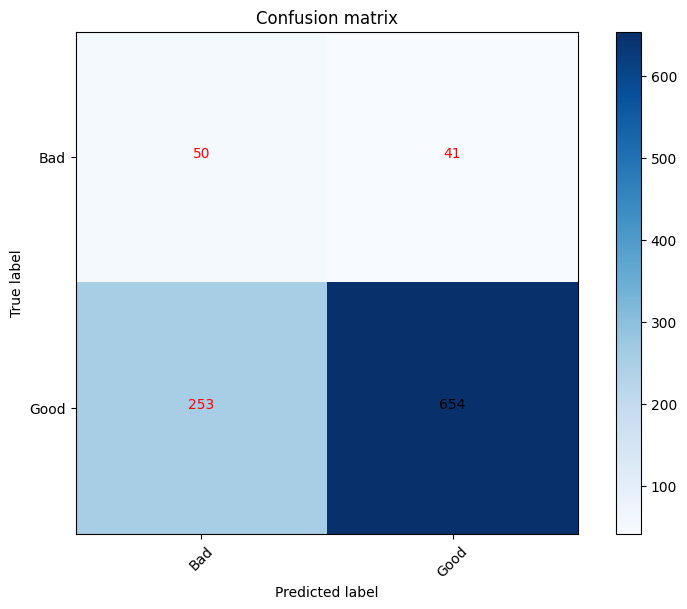

In [60]:
new_df = temp
# new_df = temp
predictions = new_df['prediction'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
new_df = temp[temp['date']=='2024-11-26']
# new_df = temp
predictions = new_df['prediction'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# Final daily data testing

In [57]:
src_dir = '/kaggle/working/Final Data/Sardine'

In [58]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            pred = predict_single_image_v4(seg_img)
            predictions.append(pred)

Bad: 100%|██████████| 28/28 [00:38<00:00,  1.36s/it]


# s3 daily data till 12/01

Classification Report:

              precision    recall  f1-score   support

         Bad       0.18      0.17      0.17        53
        Good       0.98      0.98      0.98      1918

    accuracy                           0.96      1971
   macro avg       0.58      0.57      0.58      1971
weighted avg       0.96      0.96      0.96      1971

Confusion matrix, without normalization


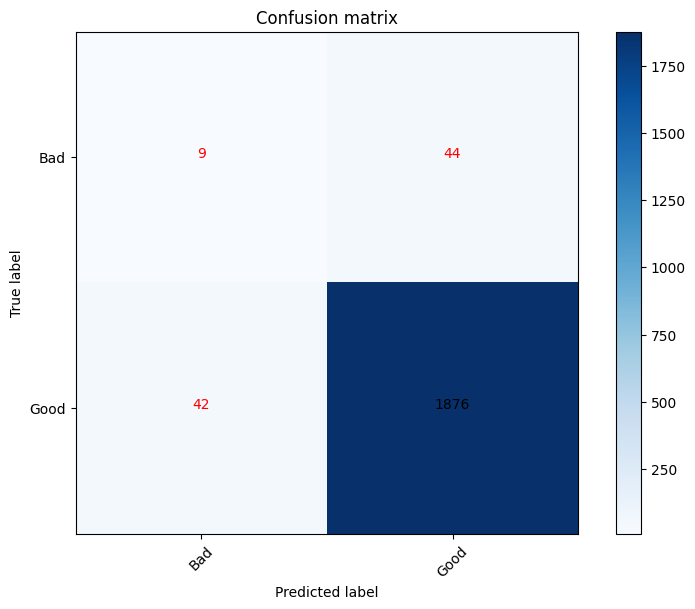

In [59]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
img_path = '/kaggle/working/input/2024-11-26/sardine/Bad/2024-11-26_09:38:47_(15047)_sardine_input.jpeg'
plt.imshow(cv2.imread(img_path));
plt.axis('off');

# app testing data on 11/26

Classification Report:

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00         2
        Good       0.93      0.93      0.93        30

    accuracy                           0.88        32
   macro avg       0.47      0.47      0.47        32
weighted avg       0.88      0.88      0.88        32

Confusion matrix, without normalization


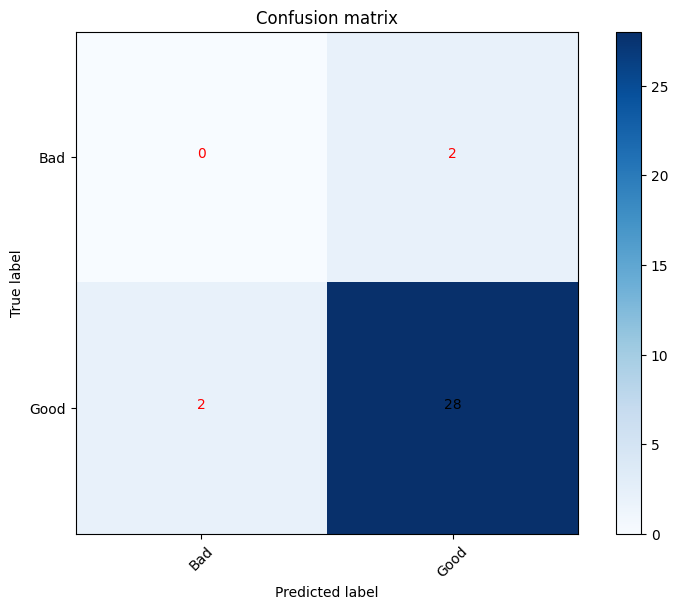

In [61]:
new_df = temp[temp['date']=='2024-11-26']
# new_df = temp
predictions = new_df['prediction'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# app testing data on 11/21

Classification Report:

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00         0
        Good       1.00      0.97      0.99       119

    accuracy                           0.97       119
   macro avg       0.50      0.49      0.49       119
weighted avg       1.00      0.97      0.99       119

Confusion matrix, without normalization


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


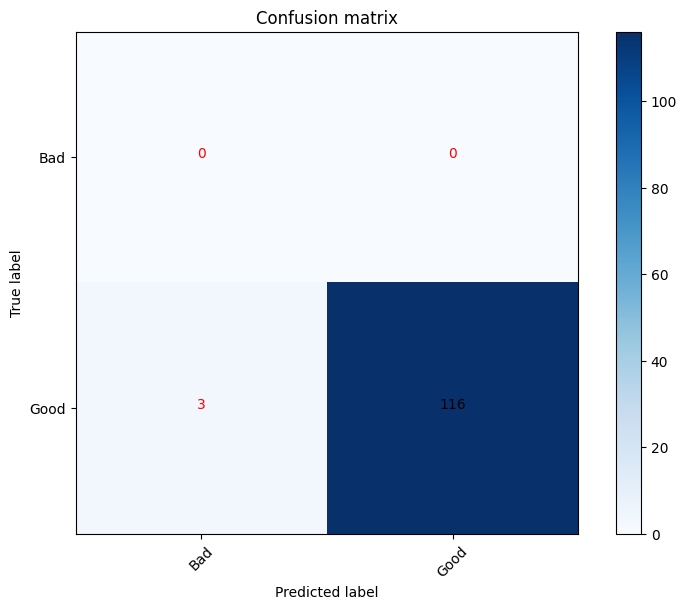

In [62]:
new_df = temp[temp['date']=='2024-11-21']
# new_df = temp
predictions = new_df['prediction'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# app testing data on 11/19

Classification Report:

              precision    recall  f1-score   support

         Bad       0.67      0.08      0.15        24
        Good       0.88      0.99      0.93       159

    accuracy                           0.87       183
   macro avg       0.77      0.54      0.54       183
weighted avg       0.85      0.87      0.83       183

Confusion matrix, without normalization


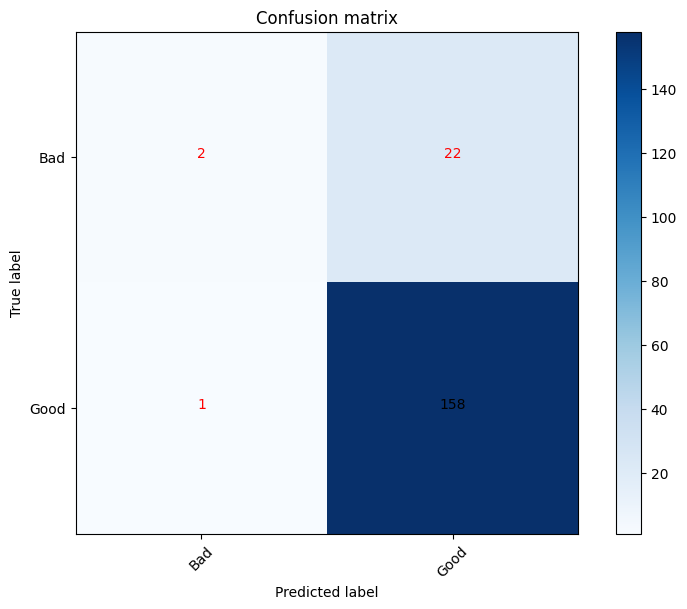

In [63]:
new_df = temp[temp['date']=='2024-11-19']
# new_df = temp
predictions = new_df['prediction'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# app testing data on 11/14

Classification Report:

              precision    recall  f1-score   support

         Bad       0.05      0.33      0.09         3
        Good       0.98      0.82      0.89        99

    accuracy                           0.80       102
   macro avg       0.51      0.58      0.49       102
weighted avg       0.95      0.80      0.87       102

Confusion matrix, without normalization


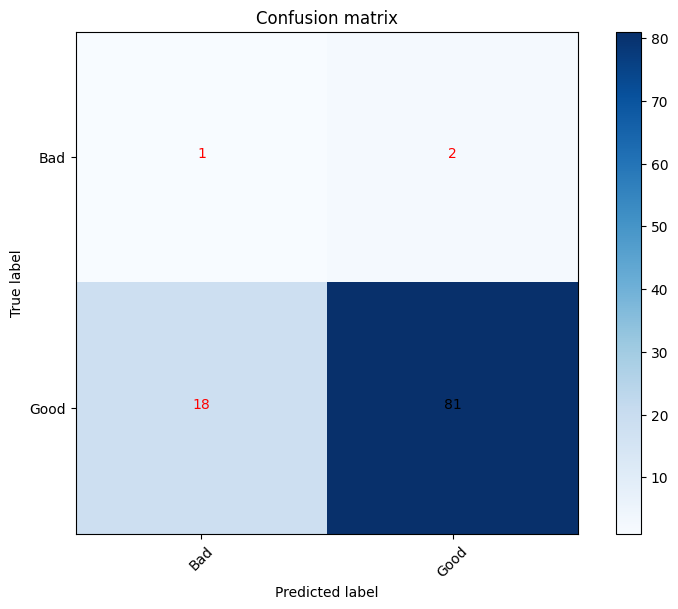

In [64]:
new_df = temp[temp['date']=='2024-11-14']
# new_df = temp
predictions = new_df['prediction'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
src_dir = '/kaggle/working/input/2024-10-29/sardine'

## BGR images

In [ ]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            seg_img = cv2.cvtColor(seg_img, cv2.COLOR_RGB2BGR)
            pred = predict_single_image_v4(seg_img)
            predictions.append(pred)

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

## RGB images

In [ ]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            pred = predict_single_image_v4(seg_img)
            predictions.append(pred)

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
def predict_single_image_v4(img):
    img = cv2.resize(img, (224, 224))
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = tf.expand_dims(img_array, axis=0)
#     img_array = tf.cast(img_array, tf.float32)
    labeling = infer(img_array)
    pred = 1 if labeling['output_0'].numpy()[0][0] >= 0.5 else 0    
    return pred

In [ ]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            pred = predict_single_image_v4(seg_img)
            predictions.append(pred)

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
src_dir = '/kaggle/working/input/2024-10-24/sardine'

In [ ]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            pred = predict_single_image_v4(seg_img)
            predictions.append(pred)

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

## predict_single_image_v5

In [ ]:
def predict_single_image_v5(img):
    img = tf.image.resize(img, (224, 224))
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = tf.expand_dims(img_array, axis=0)
    labeling = infer(img_array)
    pred = 1 if labeling['output_0'].numpy()[0][0] >= 0.5 else 0    
    return pred

In [ ]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            pred = predict_single_image_v5(seg_img)
            predictions.append(pred)

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [ ]:
src_dir = '/kaggle/working/input/2024-10-29/sardine'

In [ ]:
true_labels = []
predictions = []
for f in os.listdir(src_dir):
    folder_path = os.path.join(src_dir, f)
    l = [os.path.join(folder_path, img) for img in os.listdir(folder_path)]
    for img_path in tqdm(l, desc=f):
        seg_img_list = segment_img(img_path, seg_model)
        if seg_img_list is None: continue
        for i, seg_img in enumerate(seg_img_list):
            if f=='Good':
                true_labels.append(1)
            else:
                true_labels.append(0)
            pred = predict_single_image_v5(seg_img)
            predictions.append(pred)

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

# App testing workflow 

In [65]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    

def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
#     img = cv2.imread(img_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for mask in masks:
#         mask = masks[index]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        x1, y1, x2, y2 = (x, y, x+w, y+h)
        box = [x1, y1, x2, y2]
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w]
        # white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list

def segment_img(img_path, fish_model):
    results = fish_model(img_path, imgsz=640, conf=0.75, iou=0.7, verbose=False)
    if not results[0].masks: return None
    seg_img_list = get_segmented_img(results[0])
    return seg_img_list

# Loading required models


In [66]:
from ultralytics import YOLO
fish_model = YOLO('/kaggle/input/unseen-tomato-images-dataset/fish.pt')
cuts_damages_model = YOLO("/kaggle/input/app-model-files/cut-seg.pt")
scale_model = YOLO("/kaggle/input/app-model-files/scale_detection_model.pt")
savedmodel_path = "/kaggle/input/unseen-tomato-images-dataset/sardine_model_20epochs_k_gpu/kaggle/working/sardine_model_20epochs_k_gpu"
loaded = tf.saved_model.load(savedmodel_path)
infer = loaded.signatures["serving_default"]
softness_model = infer

In [67]:
size_based_model_path = "/kaggle/input/app-model-files/Logistic Regression.pkl"

import pickle
def load_size_based_model(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model
size_based_model = load_size_based_model(size_based_model_path)

In [68]:
size_based_model.feature_names_in_

array(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 'Circumference(cm)', 'Area(cm)'], dtype=object)

## cuts and damages utils

In [69]:
def process_image2(image, size=(640, 640)): # for eye model
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    return np.asarray(padded_image)

def is_cut(image):
    img = process_image2(image)
    img = image[:,:,::-1]
    res = cuts_damages_model.predict(img, conf=0.5, verbose=False)
    if len(res[0].boxes.xyxy) == 0:
        return False
    else:
        return True

# size based model utils

In [70]:
def circumference_area(img):
    # Load the segmented fish image
    # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Threshold the image to create a binary mask
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ensure at least one contour was found
    if len(contours) > 0:
        # Get the largest contour (presumably the fish)
        largest_contour = max(contours, key=cv2.contourArea)

        # Calculate the circumference of the contour
        circumference = cv2.arcLength(largest_contour, closed=True)

        # Calculate the area enclosed by the contour
        area = cv2.contourArea(largest_contour)
        return circumference, area
    else:
        return 0, 0
    
    
def get_object_height(results, index=0):
    import math
    hp = int(results[0].boxes.xywh[index][3])
    wp = int(results[0].boxes.xywh[index][2])
    dp = int(math.hypot(hp, wp))
    if hp<wp: (hp, wp) = (wp, hp)
    # else: hp, wp, dp = (0, 0, 0)
    return hp, wp, dp

def pixel_to_cm(fish_hp, fish_wp, fish_dp, scale_hp, scale_wp, scale_dp):
    try:
        scale_hcm = 13
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm,
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm,
            scale_wcm, one_pixel_value)

def single_img_data(fish_hp, fish_wp, fish_dp,
                    scale_hp, scale_wp, scale_dp,
                    fish_img):
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm,
     one_pixel_value) = pixel_to_cm(fish_hp, fish_wp, fish_dp,
                                  scale_hp, scale_wp, scale_dp)
    
    circumference, area = circumference_area(fish_img)
    if one_pixel_value != 0:
        circumference = int(circumference * one_pixel_value)
        area = int(area * one_pixel_value * one_pixel_value)

    data = [fish_hcm, fish_wcm, fish_dcm,
                scale_dcm, scale_wcm, one_pixel_value,
                circumference, area]
    df = pd.DataFrame([data], columns=['FishHeight(cm)', 'FishWidth(cm)',
                  'FishDiagonal(cm)', 'ScaleDiagonal(cm)', 'ScaleWidth(cm)',
                  'OnePixelValue', 'Circumference(cm)', 'Area(cm)'])
    return df

def pred_single_img(test_df, model):
    label_map = {0: 'Bad', 1: 'Good'}
    probabilities = []
    for index, row in test_df.iterrows():
        X_test = test_df[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)', 
                          'Circumference(cm)', 'Area(cm)']]
        # pred = model.predict(X_test)
        # Get probability estimates for the predicted labels
        y_proba = model.predict_proba(X_test)
        probabilities.append(y_proba)
#     print(probabilities)

    # Set your chosen threshold
    threshold = 0.8
    # threshold = 0.7
    # Adjust predictions based on the threshold
    predictions = np.ones(len(probabilities))
    for i in range(len(probabilities)):
        if probabilities[i][0][0] >= threshold:
            predictions[i] = 0

    return (label_map[int(predictions[0])])

def get_segmented_img_old(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    mask = masks[index]
    mask_points = mask.astype(int)
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(binary_mask, [mask_points], 255)
    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    x, y, w, h = cv2.boundingRect(mask_points)
    x1, y1, x2, y2 = (x, y, x+w, y+h)
    box = [x1, y1, x2, y2]
    segment_image = np.zeros((height, width, 3), dtype=np.uint8)
    segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
    segment_image = segment_image[y:y+h, x:x+w]
    # white_background = False
    if white_background:
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]
    seg_img_list.append(segment_image)
    # return seg_img_list
    return seg_img_list, masks[index], box

def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
#     img = cv2.imread(img_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for mask in masks:
#         mask = masks[index]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        x1, y1, x2, y2 = (x, y, x+w, y+h)
        box = [x1, y1, x2, y2]
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w]
        # white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list

# softness model utils

In [71]:
def softness_model_predict(seg_img, model):
    img = cv2.resize(seg_img, (224, 224))
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = tf.expand_dims(img_array, axis=0)
    labeling = infer(img_array)
    pred = 'Good' if labeling['output_0'].numpy()[0][0] >= 0.5 else 'Bad'    
    return pred 

# getting final predictions for each image

In [72]:
def get_final_result(filename, results):
    num_obj_detected = len(results[0].boxes.cls)
    if num_obj_detected == 0:
        return [filename], ['No fish detected'], ['No fish detected']

    filenames, preds, reasons = [], [], []

    # cuts and damages model
    seg_img_list = get_segmented_img(results[0], True) # white background
    for i in range(len(seg_img_list)):
        if is_cut(seg_img_list[i]):
            new_filename = filename.split('.')[0]+f'_({i}).png'
            filenames.append(new_filename)
            preds.append('Bad')
            reasons.append('Cuts')

    if len(filenames) == num_obj_detected:
        return filenames, preds, reasons
    
    seg_img_list = get_segmented_img(results[0], False) # black background
    
    # scale detection model
    original_img = results[0].orig_img
    bgr_original_img = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)
    res = scale_model(bgr_original_img, imgsz=640, conf=0.5, iou=0.7, verbose=False)
    
    if len(res[0].boxes.cls)==0:
        # softness model
        for i in range(len(seg_img_list)):
            new_filename = filename.split('.')[0]+f'_({i}).png'
            if new_filename in filenames: continue
            img = seg_img_list[i]
            pred = softness_model_predict(img, softness_model)
            if pred == 'Good':
                filenames.append(new_filename)
                preds.append('Good')
                reasons.append('None')
            else:
                filenames.append(new_filename)
                preds.append('Bad')
                reasons.append('Soft')
    else:
        # size detection
        scale_hp, scale_wp, scale_dp = get_object_height(res)
        for i in range(len(seg_img_list)):
            new_filename = filename.split('.')[0]+f'_({i}).png'
            if new_filename in filenames: continue
            img = seg_img_list[i]
            fish_hp, fish_wp, fish_dp = get_object_height(results, i)
            df = single_img_data(fish_hp, fish_wp, fish_dp,
                                scale_hp, scale_wp, scale_dp, img)
            # logistic regression model
            pred = pred_single_img(df, size_based_model)
            if pred == 'Bad':
                filenames.append(new_filename)
                preds.append('Bad')
                reasons.append('Size')
            else:
                # softness model
                pred = softness_model_predict(img, softness_model)
                if pred == 'Good':
                    filenames.append(new_filename)
                    preds.append('Good')
                    reasons.append('None')
                else:
                    filenames.append(new_filename)
                    preds.append('Bad')
                    reasons.append('Softness')
    return filenames, preds, reasons

# creating df of results

In [73]:
test_data_folder = '/kaggle/working/input'
# test_data_folder = '/kaggle/working/S3 Daily Data'

import pandas as pd

if os.path.exists('test_data_results.csv'):
    df = pd.read_csv('test_data_results.csv')
else:
    df = pd.DataFrame(columns=['dates', 'filenames', 'true_labels', 'predictions', 'reasons'])

    
d = {'Good': 1, 'Bad': 0}
for date in sorted(os.listdir(test_data_folder)):
    if not os.path.exists(os.path.join(test_data_folder, date, 'sardine')): continue
    for fresh_type in tqdm(os.listdir(os.path.join(test_data_folder, date, 'sardine')), desc=date):
        fresh_type_path = os.path.join(test_data_folder, date, 'sardine', fresh_type)
        for filename in os.listdir(fresh_type_path):
            if filename in df['filenames'].values: continue
            img_path = os.path.join(fresh_type_path, filename)
            results = fish_model(img_path, imgsz=640, conf=0.75, iou=0.7, verbose=False)
            filenames, predictions, reasons = get_final_result(filename, results)
            true_labels = [fresh_type]*len(predictions)
            dates = [date]*len(predictions)
            data = {'dates': dates, 'filenames': filenames, 'true_labels': true_labels, 
                    'predictions': predictions, 'reasons': reasons}
            new_df = pd.DataFrame(data)
            df = pd.concat([df, new_df], ignore_index=True)
            df.to_csv('test_data_results.csv', index=False)

print('Done')
print(df.shape)

2024-11-26: 100%|██████████| 2/2 [00:35<00:00, 17.97s/it]

Done
(998, 5)


In [ ]:
df['filenames'].nunique()

In [ ]:
df

# results visualization

Classification Report:

              precision    recall  f1-score   support

         Bad       0.03      0.67      0.05         3
        Good       0.99      0.56      0.72       160

    accuracy                           0.56       163
   macro avg       0.51      0.61      0.39       163
weighted avg       0.97      0.56      0.70       163

Confusion matrix, without normalization


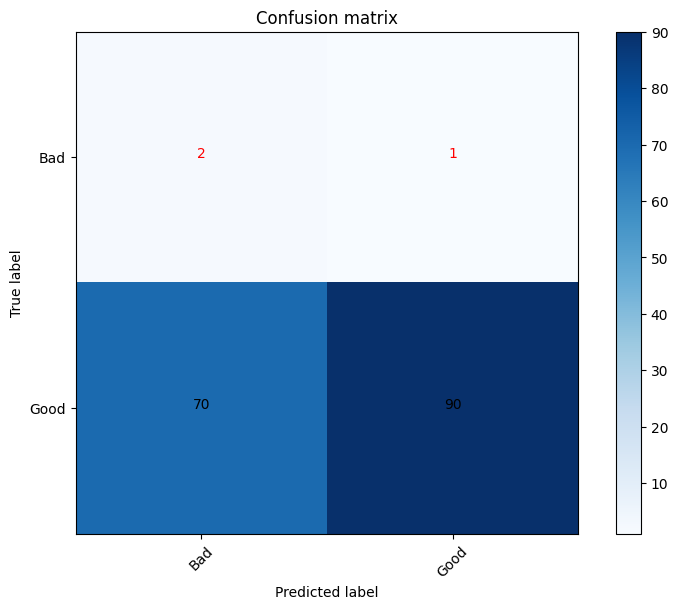

In [75]:
new_df = df[df['dates']=='2024-11-12']
# new_df = df
predictions = new_df['predictions'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

Classification Report:

              precision    recall  f1-score   support

         Bad       0.05      0.67      0.10         3
        Good       0.98      0.63      0.77        99

    accuracy                           0.63       102
   macro avg       0.52      0.65      0.43       102
weighted avg       0.96      0.63      0.75       102

Confusion matrix, without normalization


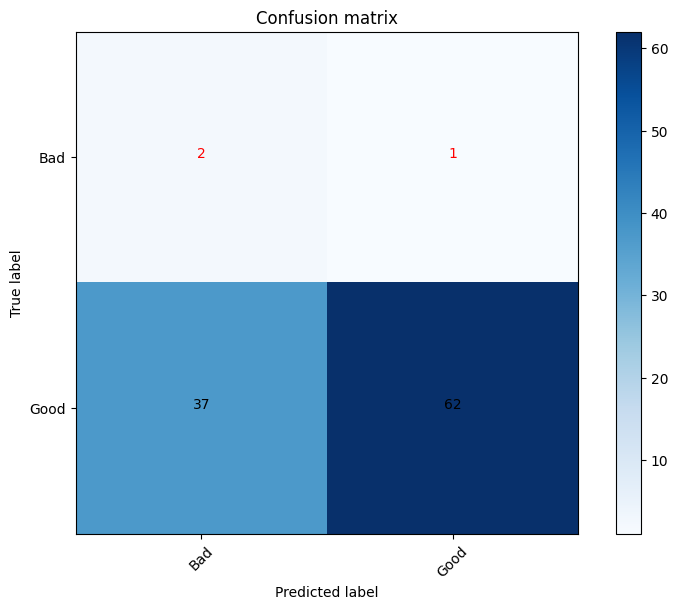

In [76]:
new_df = df[df['dates']=='2024-11-14']
# new_df = df
predictions = new_df['predictions'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

Classification Report:

              precision    recall  f1-score   support

         Bad       0.09      0.38      0.14        24
        Good       0.82      0.42      0.56       159

    accuracy                           0.42       183
   macro avg       0.45      0.40      0.35       183
weighted avg       0.72      0.42      0.50       183

Confusion matrix, without normalization


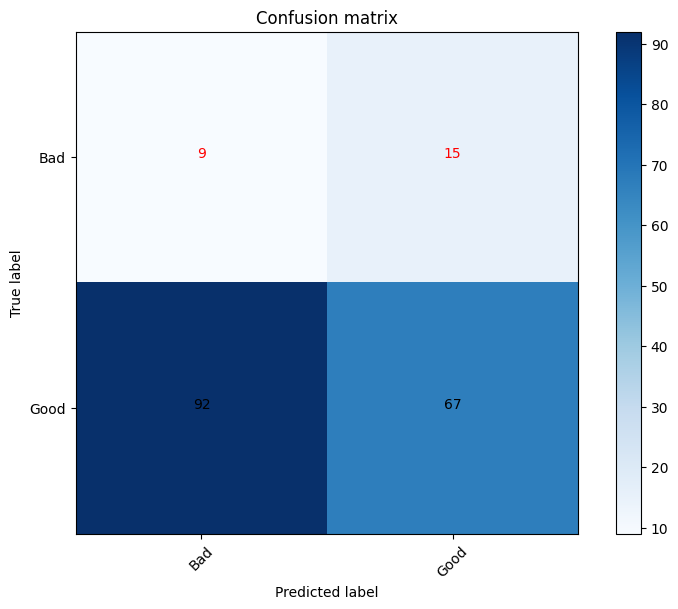

In [77]:
new_df = df[df['dates']=='2024-11-19']
# new_df = df
predictions = new_df['predictions'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

Classification Report:

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00         0
        Good       1.00      0.40      0.57       119

    accuracy                           0.40       119
   macro avg       0.50      0.20      0.29       119
weighted avg       1.00      0.40      0.57       119

Confusion matrix, without normalization


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


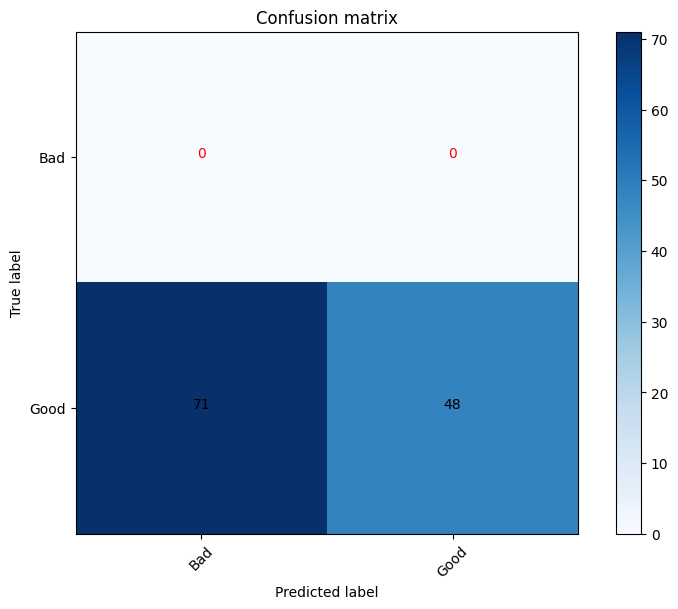

In [78]:
new_df = df[df['dates']=='2024-11-21']
# new_df = df
predictions = new_df['predictions'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

Classification Report:

              precision    recall  f1-score   support

         Bad       0.11      1.00      0.20         2
        Good       1.00      0.47      0.64        30

    accuracy                           0.50        32
   macro avg       0.56      0.73      0.42        32
weighted avg       0.94      0.50      0.61        32

Confusion matrix, without normalization


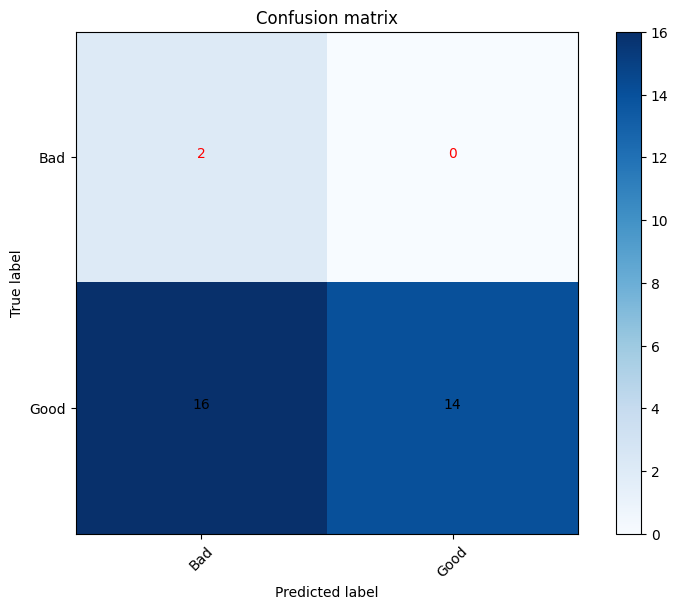

In [79]:
new_df = df[df['dates']=='2024-11-26']
# new_df = df
predictions = new_df['predictions'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

Classification Report:

              precision    recall  f1-score   support

         Bad       0.12      0.68      0.20        91
        Good       0.94      0.49      0.64       907

    accuracy                           0.50       998
   macro avg       0.53      0.58      0.42       998
weighted avg       0.86      0.50      0.60       998

Confusion matrix, without normalization


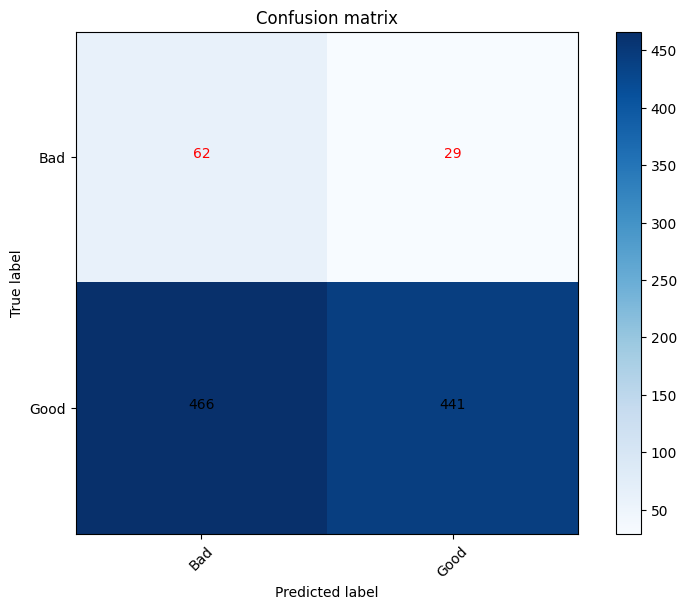

In [74]:
# new_df = df[df['dates']=='2024-11-12']
new_df = df
predictions = new_df['predictions'].values
true_labels = new_df['true_labels'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])